**Student Name**: Kaushik V

**Student Roll No**: 21f1001083


# Programming Assignment-1


There are two problems worth 100 marks. There is a problem at the end that you can attempt for bonus marks. Make a copy of the colab. Rename the colab as follows:

```
PA-1_<roll-number>.ipynb
```

We will be running your colab. It should produce the graphs/charts of the learning curves as explaind in the problem statements. Add comments wherever necessary. At the end of each problem, enter your observations in the text cell. This should include your analysis of the learning curves obtaind.

### Libraries

Stick to `NumPy` and a library such as `matplotlib`, `seaborn` or `plotly` for rendering plots.

In [2]:
# import necessary libraries here
import numpy as np
import matplotlib.pyplot as plt

## Problem 1 [65 Marks]

You will be simulating the 10-armed bandit testbed.


### Single Bandit problem

The bandit problem should have $10$ arms. For each arm, the $q_{*}(a)$ value should be sampled from a Gaussian distribution with $0$ mean and unit variance . The rewards from arm $a$ should be sampled from a Gaussian distribution with mean $q_{}(a)$  and unit variance .


### Testbed

Generate 2000 different bandit problems. Use the sample average method with incremental implementation for learning the action values. Plot the learning curves for 1000 timesteps with the following algorithms:

- gready
- $ϵ$-greedy
  - $ϵ$-0.1
  - $ϵ$-0.01

There are two learning curves for each algorithm:
- average reward vs time
- %  optimal actions vs time

You have to reproduce the following two curves:
1. Average rewards vs # of steps
2. % optimal action vs # of steps



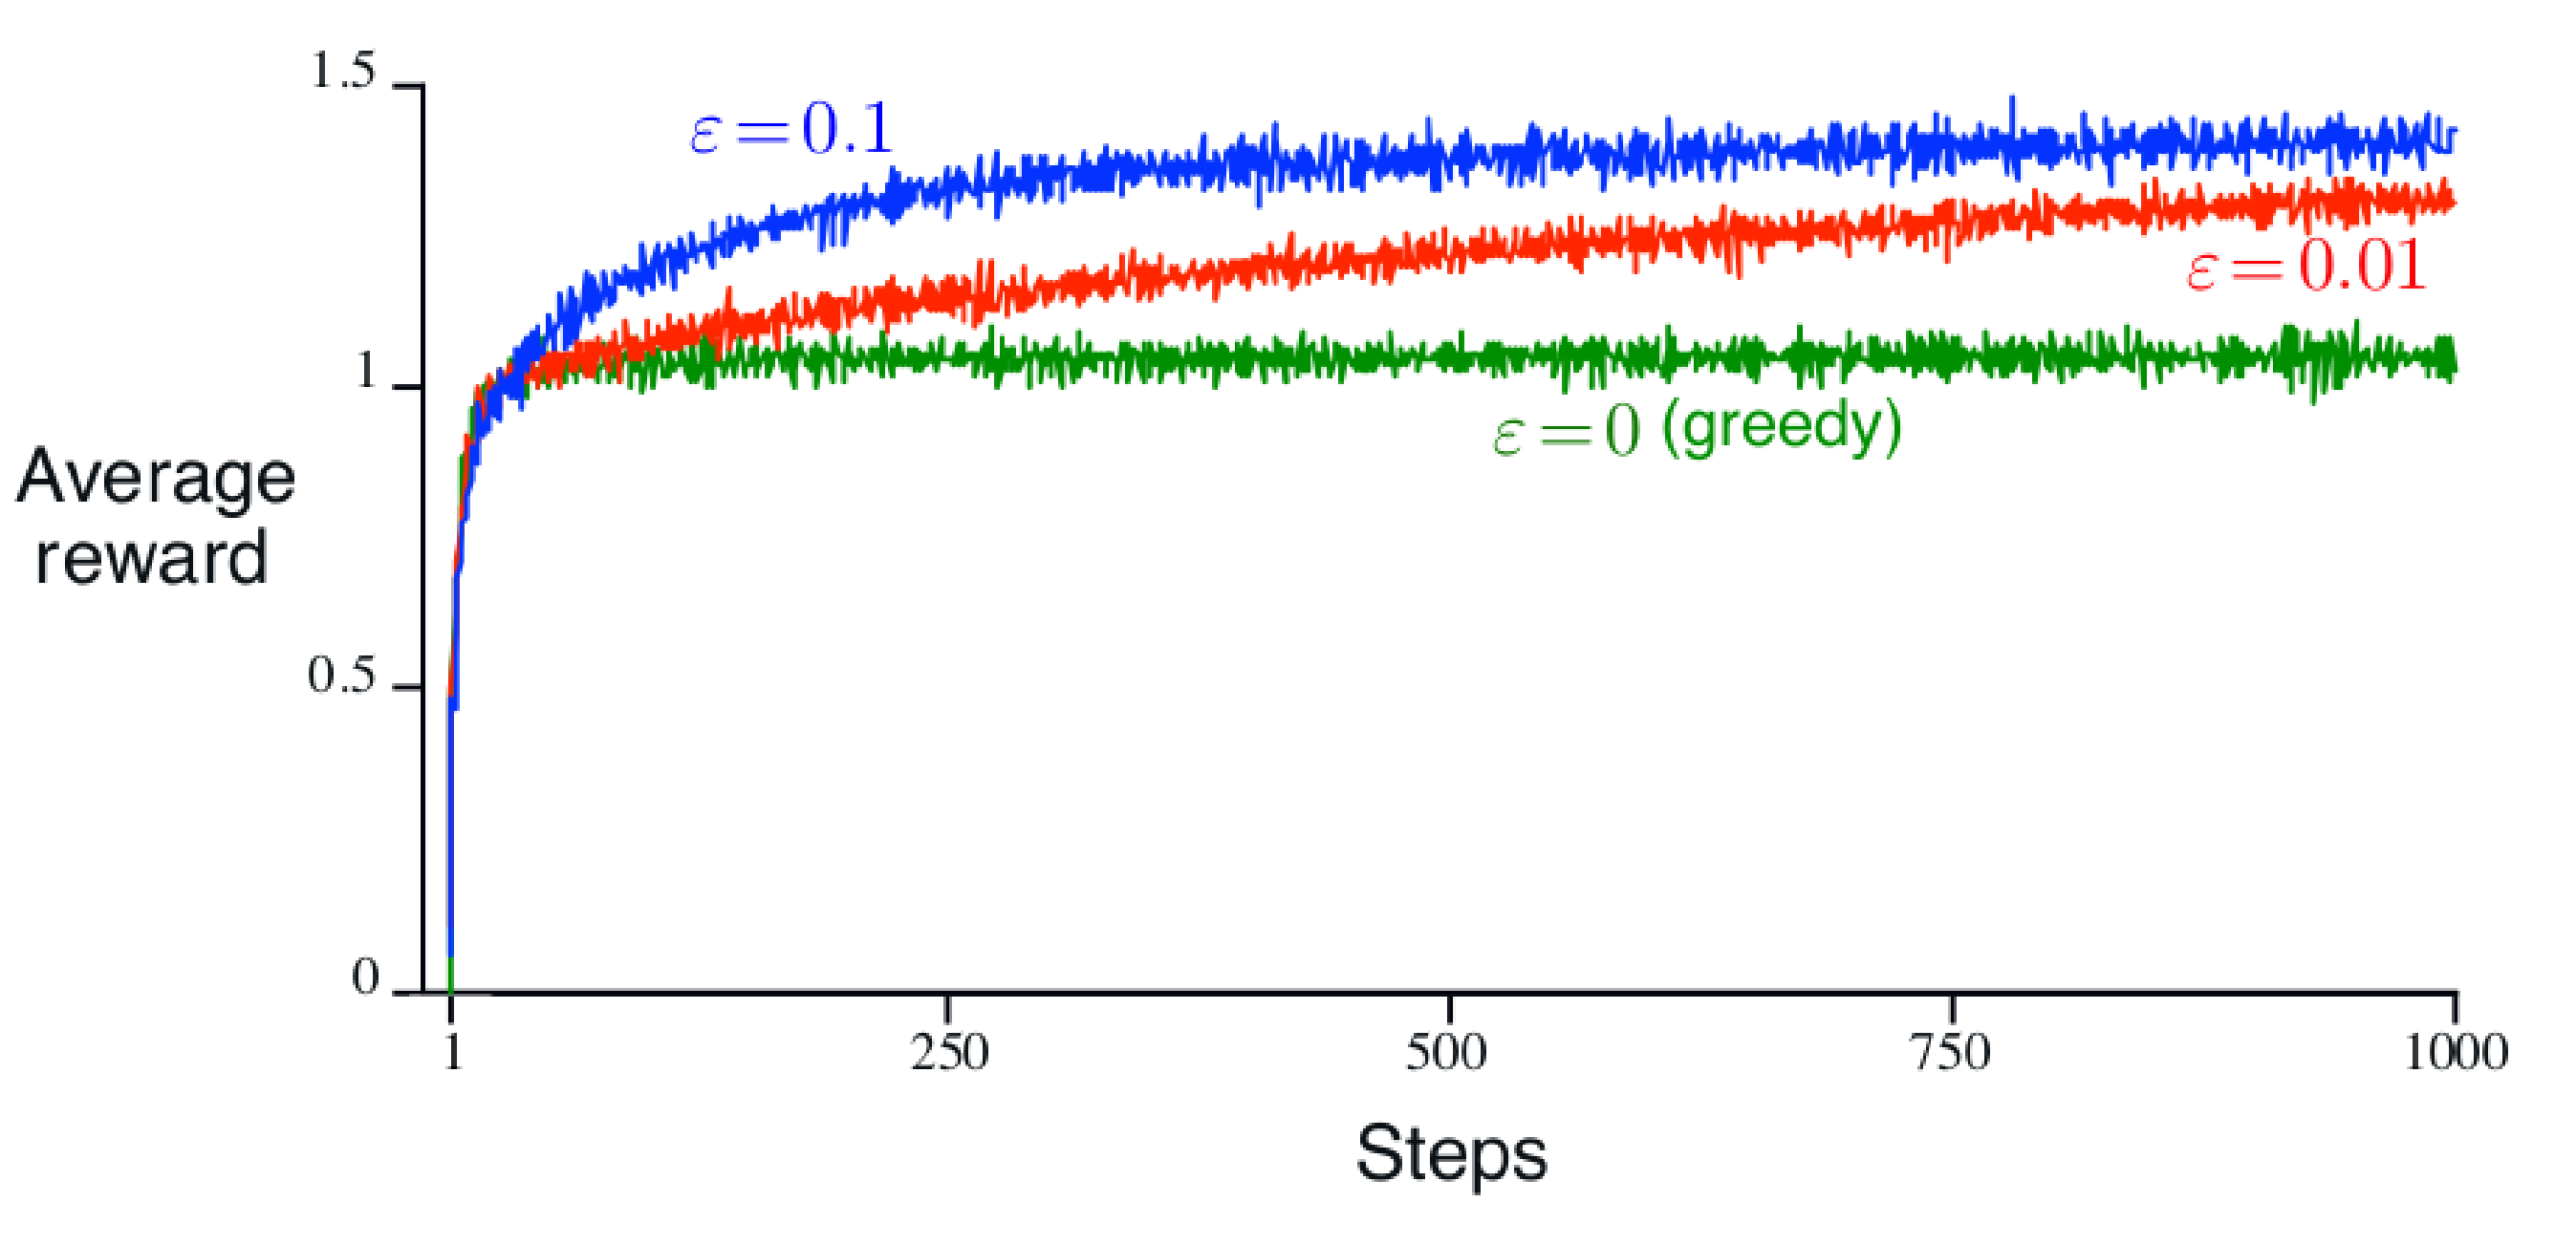

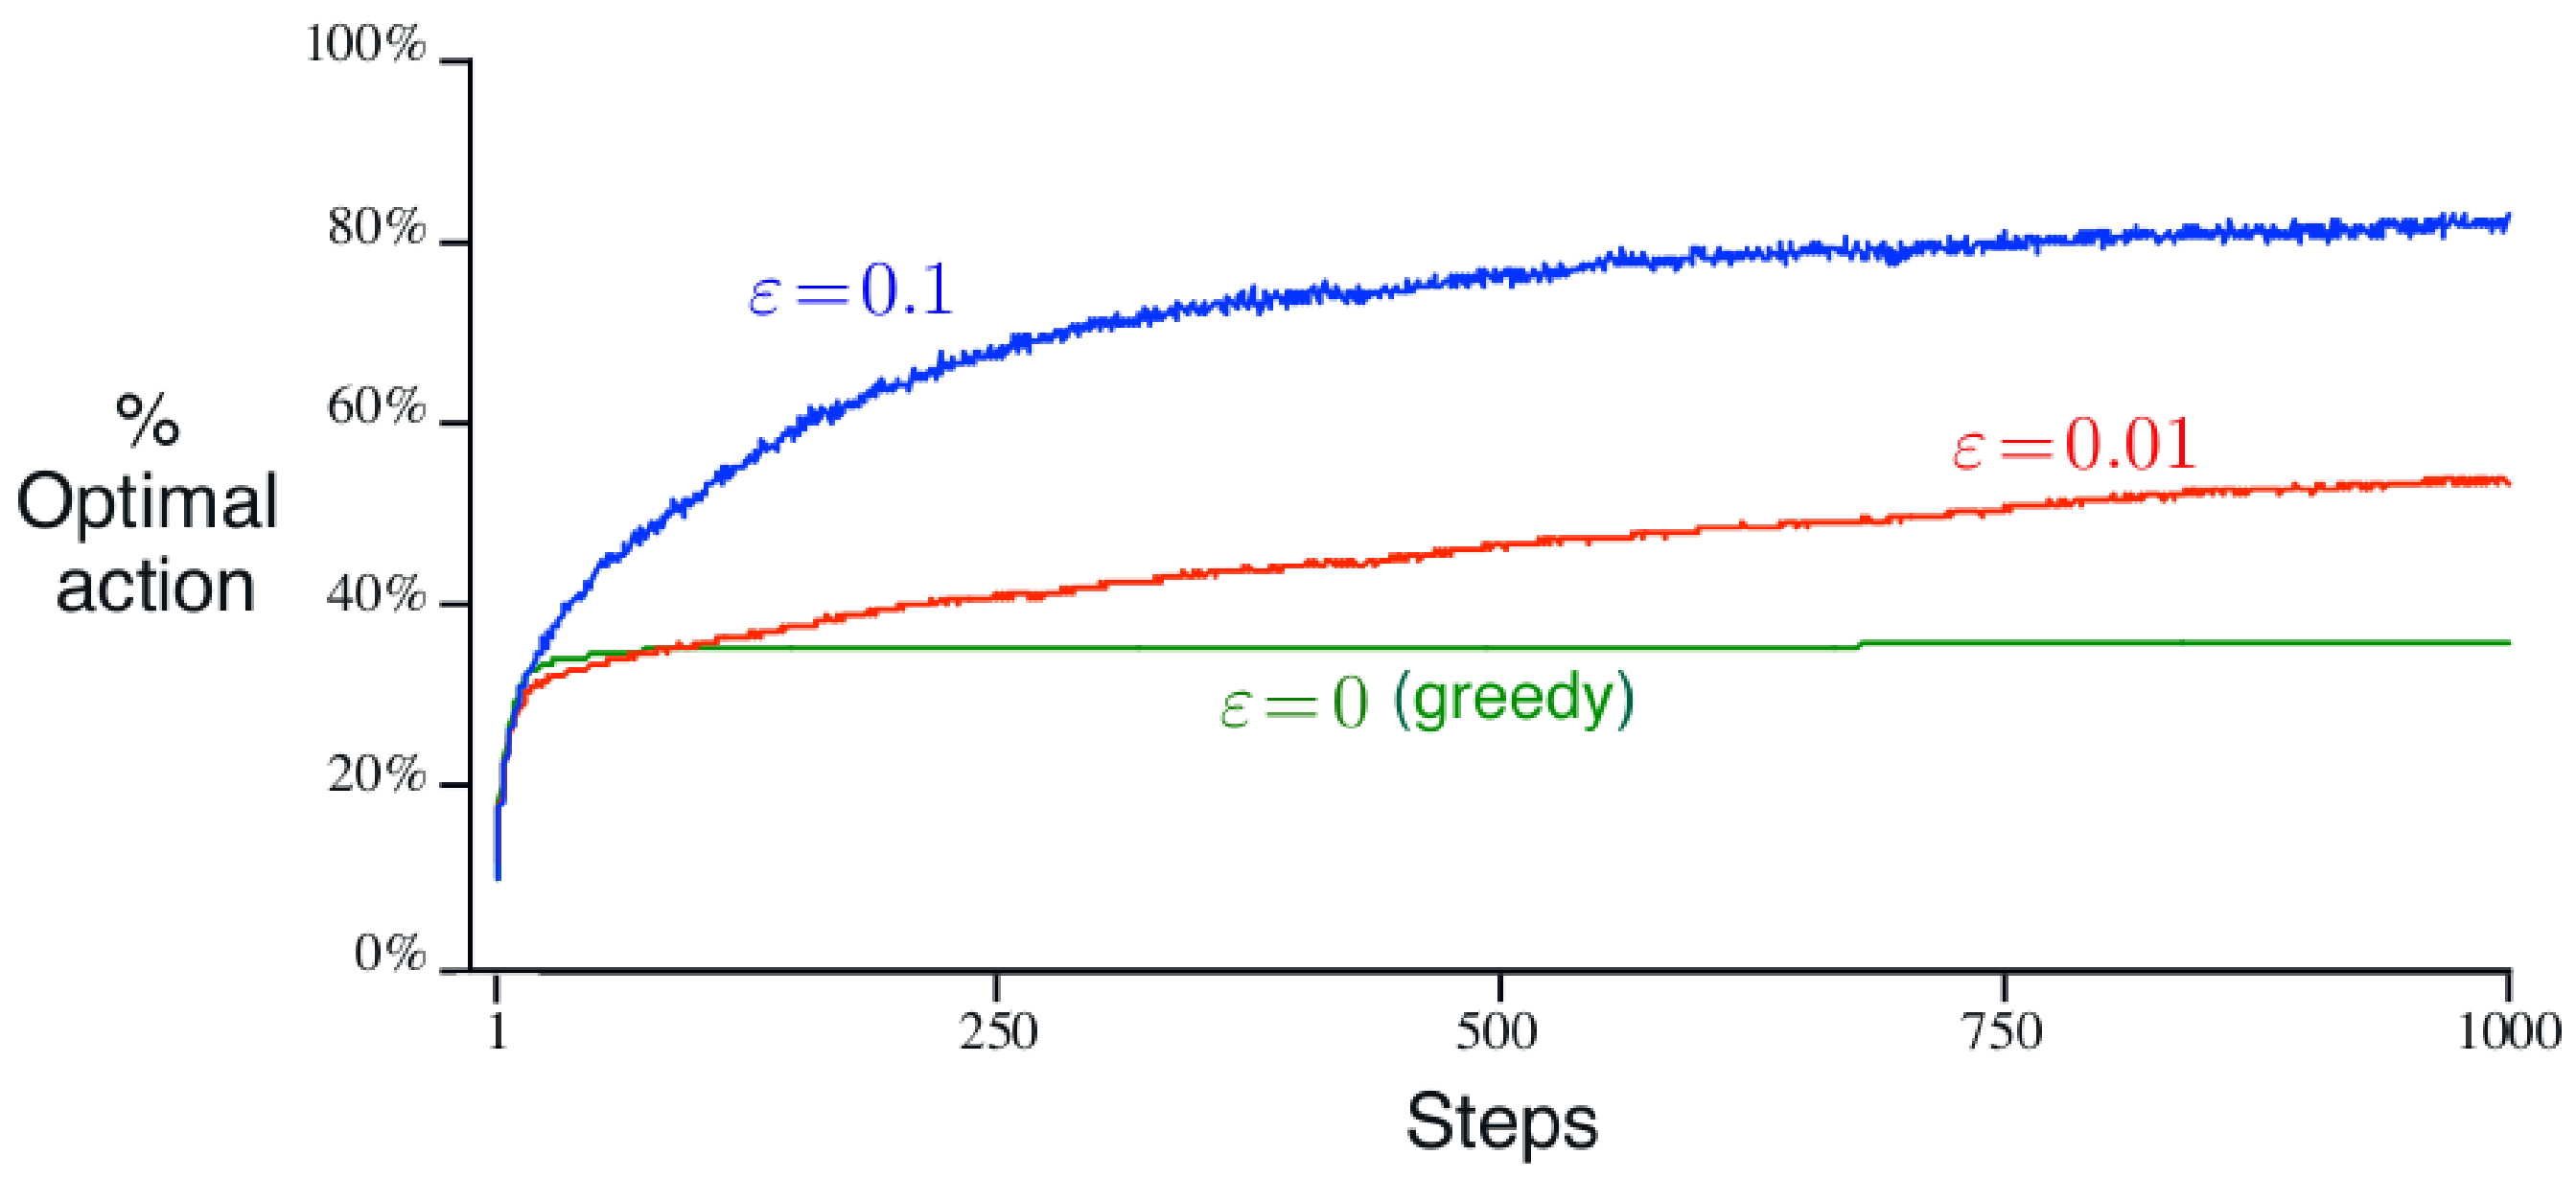

**Hint**: the averaging at each time step is done over all the 2000 bandit problems. For example, to
plot a single point $(t,r(t))$ in the "average reward plot", find the reward sampled from each of the 2000  bandits at time $t$ and compute their average. This value will be $r(t)$.

In [13]:
# write your code here for problem-1
def bandit(nbandits, narms, nsteps, method='epsilon', e=0,c=2):
# Initialisation
  rnd = np.random.default_rng() #Random generator object
  # True reward initialized for each of the arms in 2000 bandits
  q = rnd.normal(0,1,(nbandits,narms))
  # Q(a) - 2000 X 10 matrix that represents the average reward of each arm for each of the 2000 bandits
  Q = np.zeros((nbandits,narms))
  # N(a) - 2000 x 10 matrix that represents the number of times an arm has been sampled in each of the 2000 bandits
  N = np.zeros((nbandits,narms))
  # R(t) - 1000 x 1 vector that represents the average reward from 2000 bandits at each time step
  R = np.zeros(nsteps)
  #% Optimal action
  A = np.zeros(nsteps)

  #For each timestep
  for t in range(nsteps):
    tot_rwrd = 0
    optim_count=0
    for b in range(nbandits):
      # Generate a random number between 0 and 1 to choose greedy vs non-greedy strategy
      toss = rnd.random()
      #Generate reward for all arms
      rwrd_all=rnd.normal(q[b],1,(narms))
      opt_arm = np.argmax(q[b])
      # If the random number is between epsilon and 1, then choose the arm with the best Average reward. If there are multiple arms with the best average, choose one at random from them.
      if method =='ucb':
        if t > 0:
          arm = np.argmax(Q[b]+ c*np.sqrt(np.log(t)/(np.where(N[b]==0,1,N[b]))))
        else:
          arm = np.argmax(Q[b])
      else:
        if (toss > e):
          arm = np.argmax(Q[b])
        else:
          # If the random number is less than or equal to epsilon, pick any arm at random
          arm = np.random.randint(narms)
      # Find reward for the given arm
      rwrd = rwrd_all[arm]
      #Check if the arm chosen is the optimal arm
      if arm == opt_arm:
        optim_count += 1
      # N(a) = N(a) + 1
      N[b][arm] += 1
      # Q(a) = Q(a) + (R - Q(a))/N(a)
      Q[b][arm] += (rwrd - Q[b][arm])/N[b][arm]
      # Sum the reward from this bandit
      tot_rwrd += rwrd
      #print(f'Reward for Bandit {b} and arm {arm} is {rwrd} at timestep {t}')
      #print(f'At timestep {t} and bandit {b} the optimal arm was {opt_arm} and arm chosen is {arm}')
    # R(t) = Average of reward across 2000 bandits
    R[t] = tot_rwrd / nbandits
    # %Optimal action across 2000 bandits
    A[t] = 100*optim_count / nbandits
  return R, A



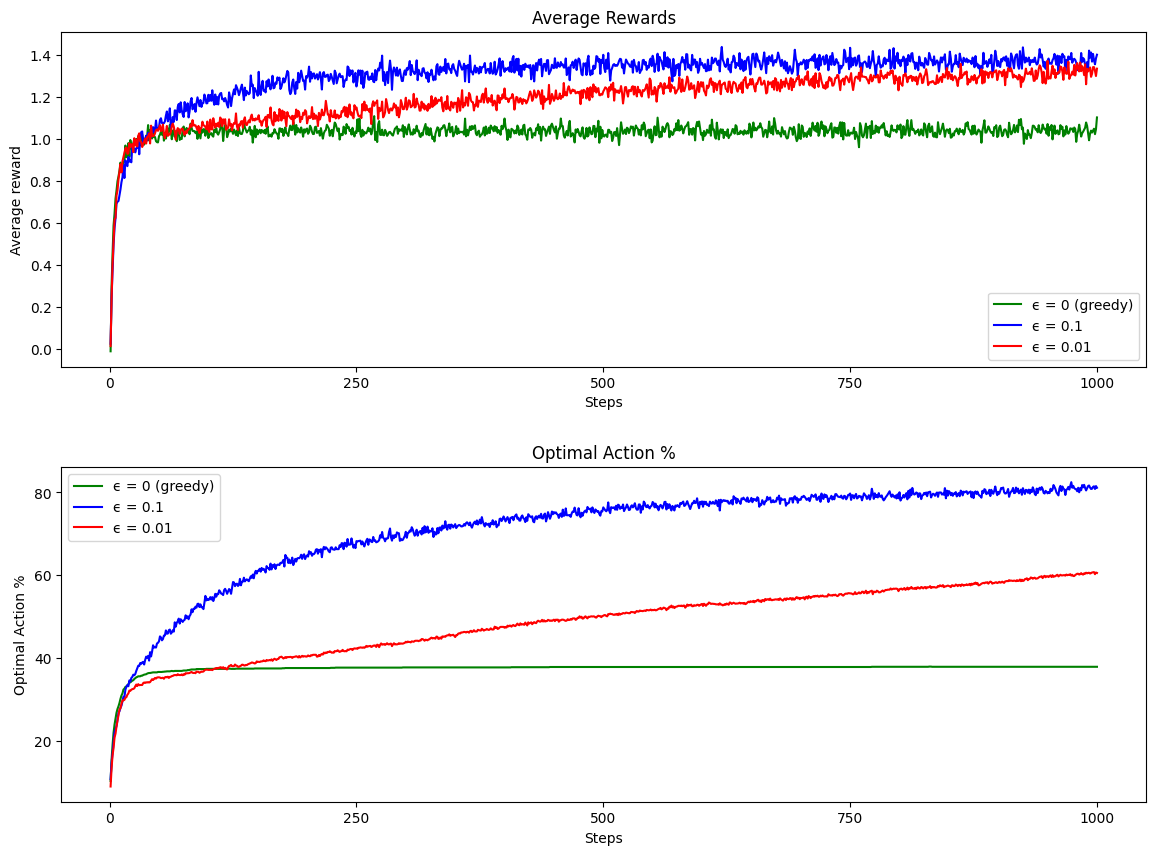

In [14]:
# Plot timestep vs average reward
bandits = 2000
arms = 10
tsteps = 1000
R1,A1 = bandit(bandits,arms,tsteps,'epsilon', 0)
R2,A2 = bandit(bandits,arms,tsteps, 'epsilon', 0.1)
R3,A3 = bandit(bandits,arms,tsteps, 'epsilon', 0.01)

t = [i for i in range(1,tsteps+1)]
fig, ax = plt.subplots(2, figsize=(14,10))
fig.subplots_adjust(hspace=0.3)
ax[0].set_title('Average Rewards')
ax[0].set_xlabel('Steps')
ax[0].set_ylabel('Average reward')
ax[0].set_xticks(np.arange(0, tsteps+1, tsteps/4))
ax[0].set_yticks(np.arange(0, 2.0, 0.2))
ax[0].plot(t,R1,c='green')
ax[0].plot(t,R2,c='blue')
ax[0].plot(t,R3,c='red')
ax[0].legend(['ϵ = 0 (greedy)','ϵ = 0.1','ϵ = 0.01'])

ax[1].set_title('Optimal Action %')
ax[1].set_xlabel('Steps')
ax[1].set_ylabel('Optimal Action %')
ax[1].set_xticks(np.arange(0, tsteps+1, tsteps/4))
ax[1].set_yticks(np.arange(0, 100, 20))
ax[1].plot(t,A1,c='green')
ax[1].plot(t,A2,c='blue')
ax[1].plot(t,A3,c='red')
ax[1].legend(['ϵ = 0 (greedy)','ϵ = 0.1','ϵ = 0.01','UCB (c=2)'])
plt.show()


### Observations from problem-1

The following are the observations made from the above run
1. Greedy approach levels off around average reward of 1, because it is does not explore other possibilities of higher rewards
2. Epsilon greedy with $\epsilon$ = 0.1 converges faster to a higher reward around 1.4 as it is exploring 10% of the time leading to discovery of arms yielding higher rewards
3. Epsilon greedy with $\epsilon = 0.01$ converges rather slowly as it is only exploring newer arms only 1% of the times
4. Consequently, greedy approach is taking optimal action by finding the optimal arm only about 30% of the times compared to epsilon greedy (0.1) eventually taking optimal action more than 80% of the times.
5. Increase in the number of bandits will normalise the reward around the given mean with lesser fluctuation, while increasing the number of timesteps may help epsilon greedy approaches with $\epsilon = 0.01$ eventually converge towards higher reward.

## Problem 2 [35 Marks]

Run the UCB algorithm on the ten-armed testbed. Plot the learning curve for UCB and compare it with $\epsilon$-greedy for $\epsilon = 0.1$. Reproduce the following learning curves averaged over 2000  bandits for 1000 timesteps:

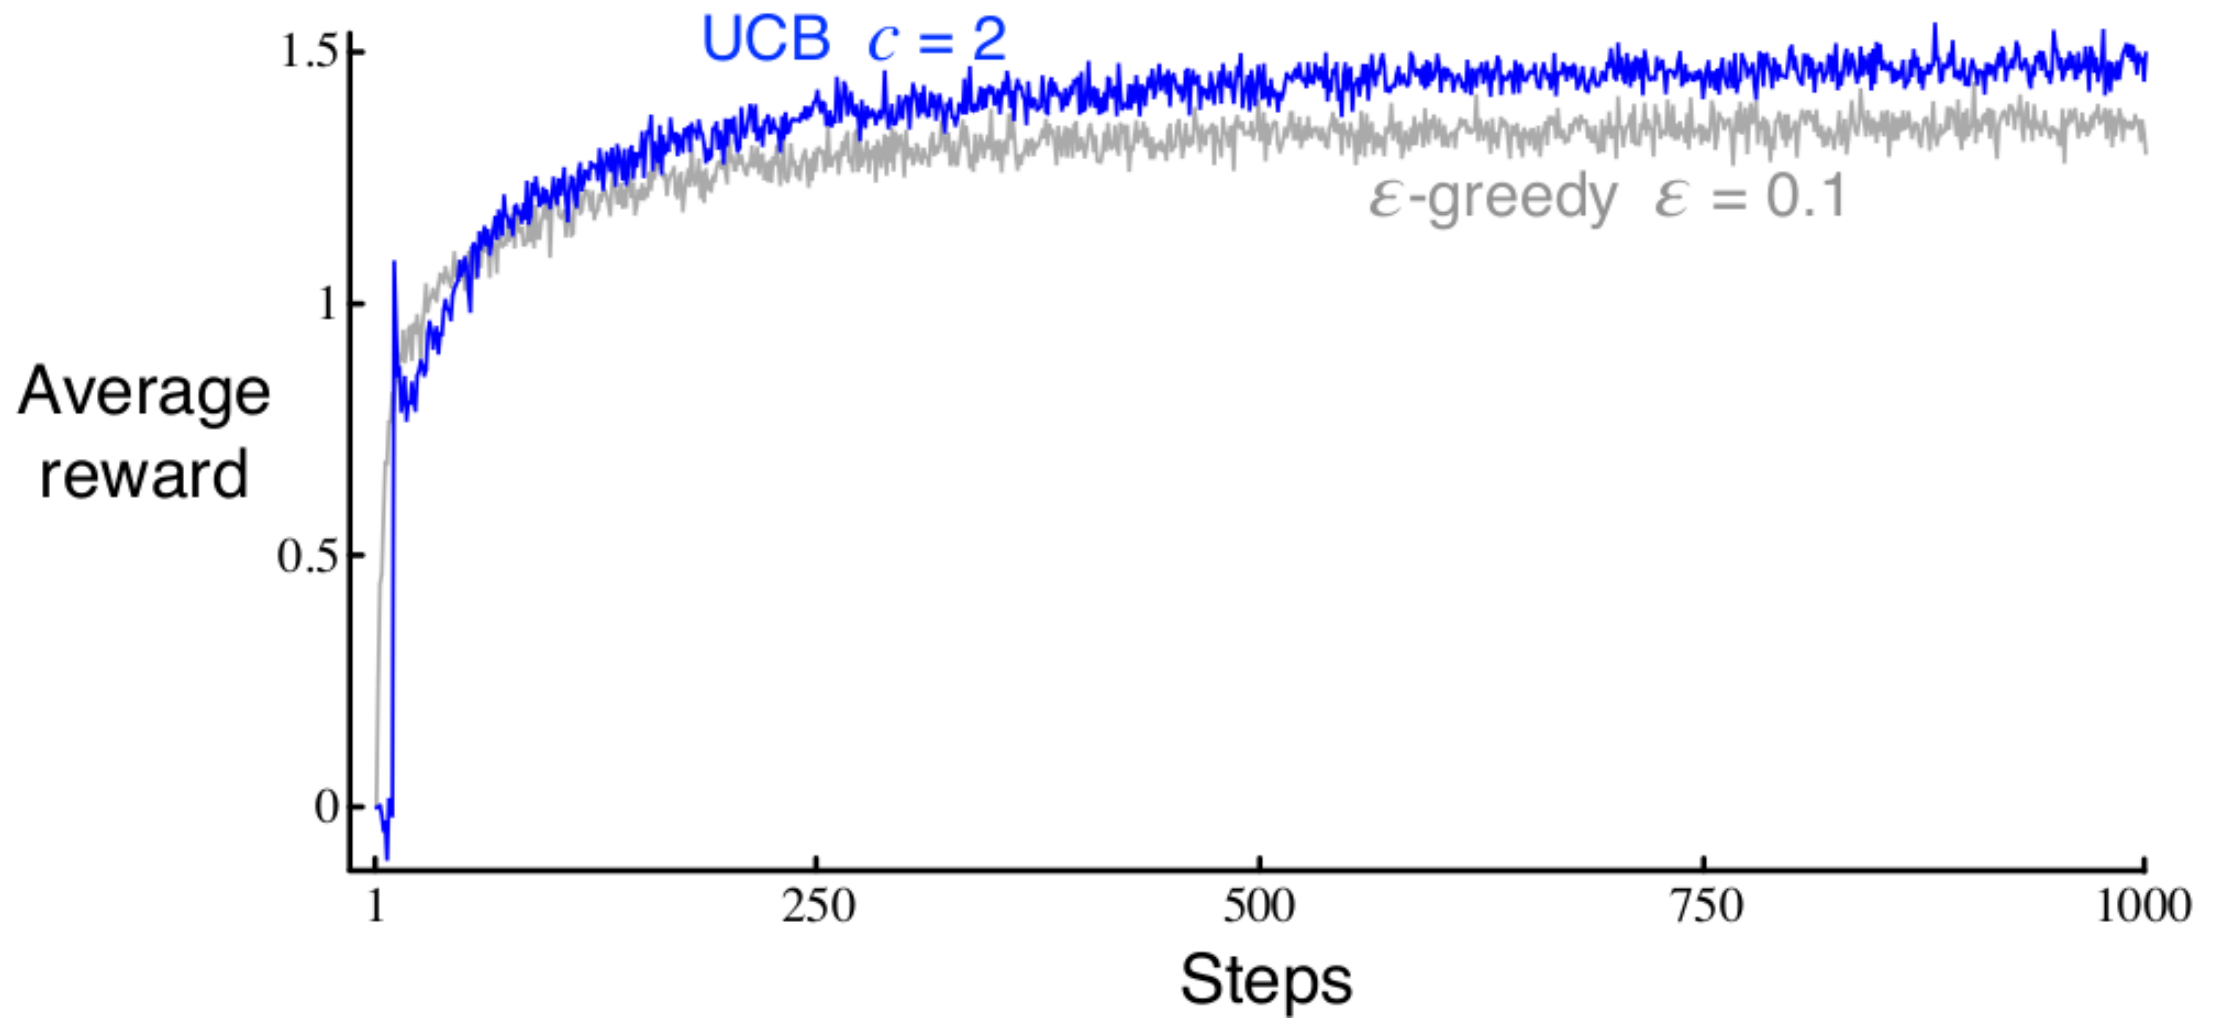

***Note:*** Refer to the textbook version of UCB algorithm.

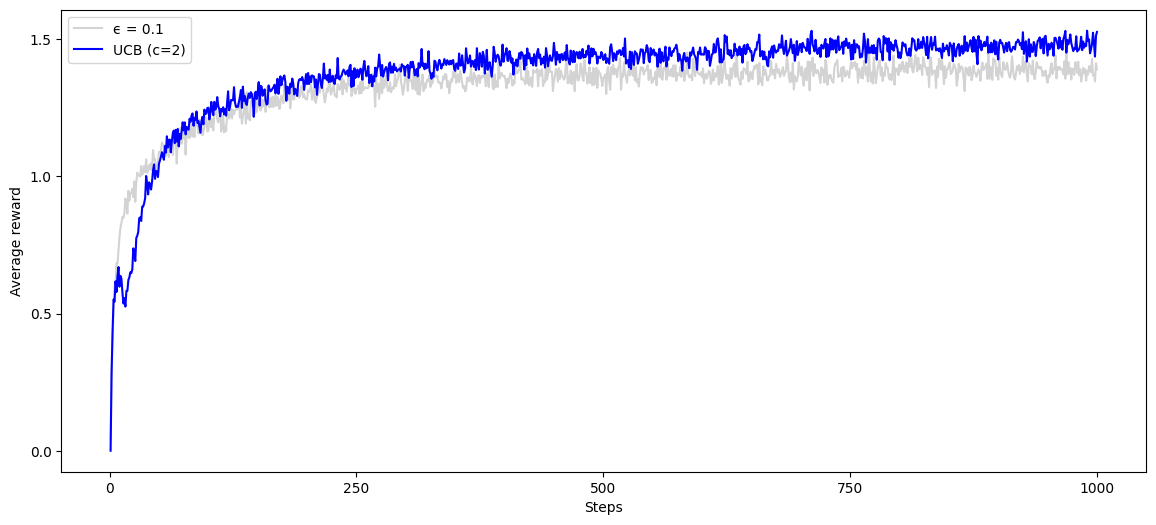

In [15]:
# write your code here for problem-2
# Plot timestep vs average reward
bandits = 2000
arms = 10
tsteps = 1000
R2,A2 = bandit(bandits,arms,tsteps, 'epsilon', 0.1)
R4,A4 = bandit(bandits,arms,tsteps, 'ucb', 0)

t = [i for i in range(1,tsteps+1)]
plt.figure(figsize=(14,6))
plt.xlabel('Steps')
plt.ylabel('Average reward')
plt.xticks(np.arange(0, tsteps+1, tsteps/4))
plt.yticks(np.arange(0, 2.0, 0.5))
plt.plot(t,R2,c='lightgray')
plt.plot(t,R4,c='blue')
plt.legend(['ϵ = 0.1','UCB (c=2)'])
plt.show()

### Observations from problem-2

The observations made are:
1. UCB discovers higher reward than epsilon greedy $\epsilon = 0.1$ as it is being explorative based on a confidence bound given by $Q(a) + c \sqrt{\frac{ln(t)}{N_{(a)}}}   $.
2. Initially epsilon greedy converges faster, however UCB progresses much faster to discover higher average reward.
3. Here too, increasing the number of bandits would normalise the average reward, while increasing the timesteps will help converge to mean reward.

## Bonus Problem [10 Marks]

Solve problems 1 and 2 for $10,000$ arms. Appropriately choose number of samples/epochs for each problem.

This code takes 60 mins

In [26]:
# write your code here for the bonus problem
bandits = 200
arms = 10000
tsteps = 10000
R1,A1 = bandit(bandits,arms,tsteps,'epsilon', 0)
R2,A2 = bandit(bandits,arms,tsteps, 'epsilon', 0.1)
R3,A3 = bandit(bandits,arms,tsteps, 'epsilon', 0.01)
R4,A4 = bandit(bandits,arms,tsteps, 'ucb', 0)


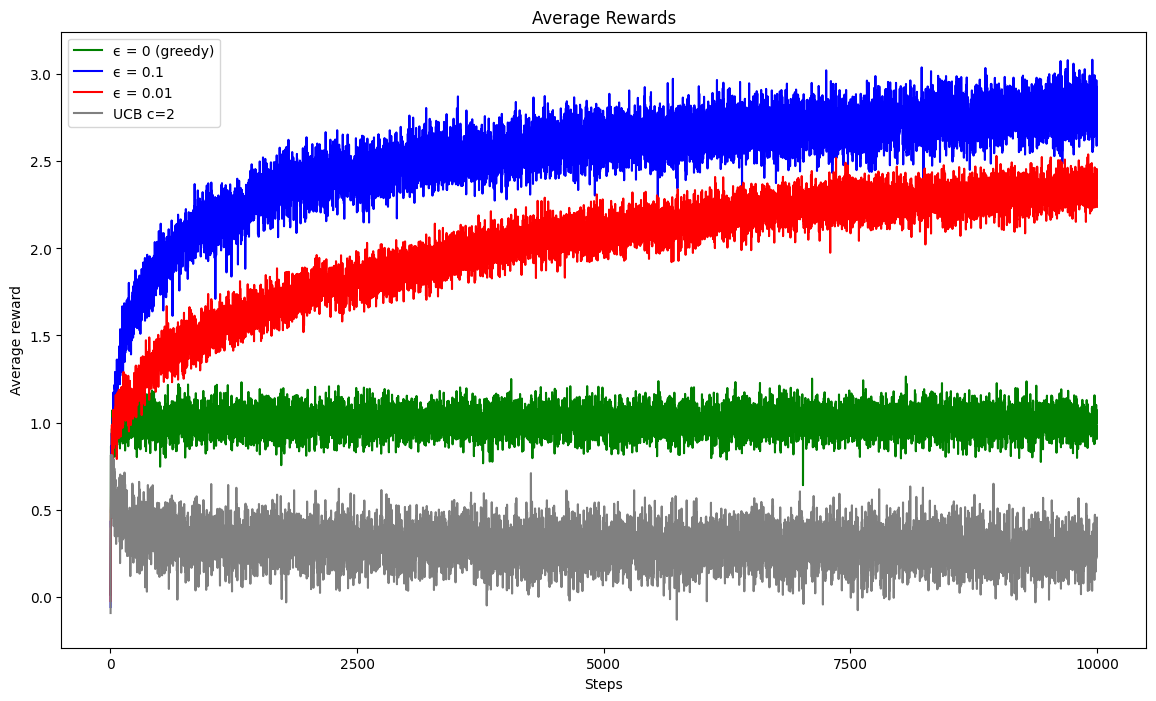

In [32]:
t = [i for i in range(1,tsteps+1)]
plt.figure(figsize=(14,8))
plt.title('Average Rewards')
plt.xlabel('Steps')
plt.ylabel('Average reward')
plt.xticks(np.arange(0, tsteps+1, tsteps/4))
plt.yticks(np.arange(0, 3.5, 0.5))
plt.plot(t,R1,c='green')
plt.plot(t,R2,c='blue')
plt.plot(t,R3,c='red')
plt.plot(t,R4,c='gray')
plt.legend(['ϵ = 0 (greedy)','ϵ = 0.1','ϵ = 0.01', 'UCB c=2'])
plt.show()


### Observations from bonus problem

Observations made were:
1. The primary observation is that UCB does not converge because the number of time steps is the same as the arms and therefore, the arms would have been selected barely once. Therfore many more timesteps would be required by UCB to start converging
2. As the number of bandits is low (200), one can observe large fluctuations in the average reward
3. While the greedy approach does not become any better with increase in arms and timesteps, we can the overall reward discovered by epsilon greedy is much higher around 2.5.